# **Sentiment Classification Using Embeddings**

## Introduction

Social media is full of opinions, and understanding the sentiment behind them is extremely valuable.

In this project, I built a system to classify tweets as:

• Positive  
• Negative  
• Neutral  

I started by experimenting with traditional machine learning models like Logistic Regression and XGBoost using sentence embeddings.  
To further improve the results, I fine-tuned a transformer model directly on the tweets, which became the final and best-performing model.

This project demonstrates:

- Text preprocessing and data cleaning  
- Exploratory Data Analysis (EDA)  
- Training and evaluating models like Logistic Regression and XGBoost  
- Fine-tuning a transformer for sentiment classification  
- Evaluating performance using classification report and confusion matrix  
- Making predictions on custom tweets  


Importing essential libraries for data manipulation and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Downloading the Twitter sentiment dataset using KaggleHub for use in this project.

In [2]:
import kagglehub

path = kagglehub.dataset_download("yasserh/twitter-tweets-sentiment-dataset")

# Load Dataset

We load the dataset containing tweets and their corresponding sentiment labels.   
This dataset will be used to train and evaluate our sentiment classification model.

In [3]:
import os

print(os.listdir(path))

['Tweets.csv']


In [4]:
df = pd.read_csv(os.path.join(path, "Tweets.csv"))
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


# Text Preprocessing, Data Cleaning, and Preparation

The dataset was cleaned by selecting the required columns **(text and sentiment)** and removing missing values.

The text was converted to lowercase, and special characters, links, and mentions were removed.

This ensures clean and consistent data and improves model performance.

In [5]:
df = df[["text", "sentiment"]]
df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [6]:
df = df.dropna(subset=['text'])
df['text'].isna().sum()

np.int64(0)

In [7]:
df.head(10)

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative
5,http://www.dothebouncy.com/smf - some shameles...,neutral
6,2am feedings for the baby are fun when he is a...,positive
7,Soooo high,neutral
8,Both of you,neutral
9,Journey!? Wow... u just became cooler. hehe....,positive


We can see the text contains messy parts like **https links** and **....**.  
These need to be removed to make the text clean and usable for the model.

In [8]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

Next, we check how many tweets belong to each sentiment class.

This helps us understand the distribution of **positive**, **negative**, and **neutral** tweets in the dataset.

In [9]:
df['sentiment'].value_counts()

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

EDA helps us understand the dataset better.

We perform:

- Sentiment distribution analysis
- WordCloud visualization
- Tweet length distribution

These visualizations help identify patterns in the data.

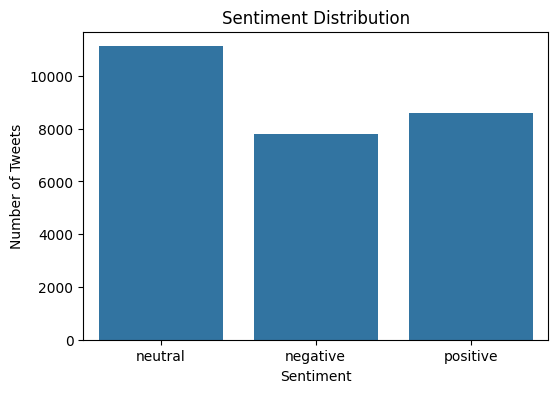

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Tweets")

plt.show()

The plot shows that neutral tweets are the most frequent, followed by positive and then negative tweets. All sentiment classes are **sufficiently** present in the dataset.

Next, a **WordCloud** is generated to see the most common words in the tweets.
This gives a quick visual understanding of the text data.

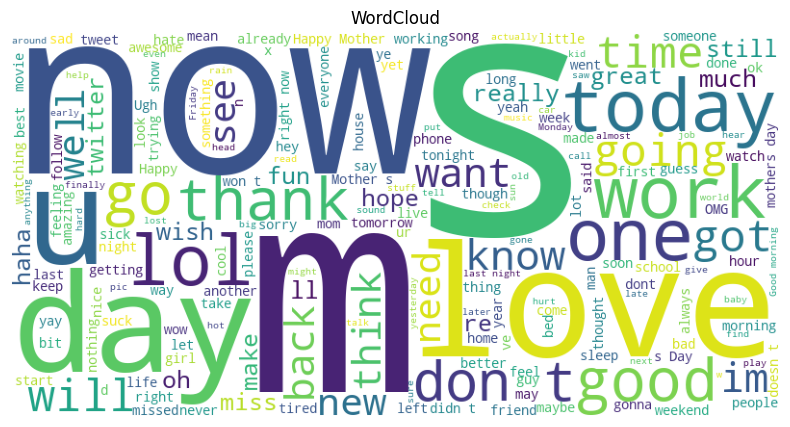

In [11]:
from wordcloud import WordCloud

text = " ".join(df["text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud")

plt.show()

From the WordCloud, we can see that words like **"now"**, **"day"**, **"love"**, and **"today"** appear more frequently in the tweets.

This gives an overview of the common words used in the dataset and helps understand the general content and language of the tweets.

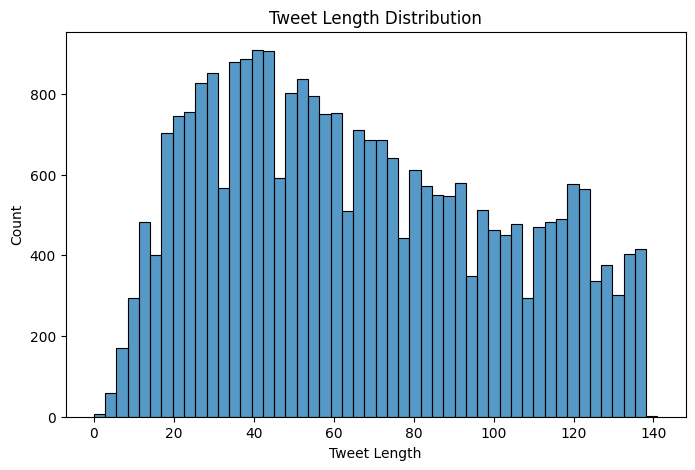

In [12]:
df["length"] = df["text"].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["length"], bins=50)

plt.title("Tweet Length Distribution")

plt.xlabel("Tweet Length")

plt.ylabel("Count")

plt.show()

The plot shows that most tweets are of medium length, with fewer extremely short or long tweets.

This provides a **balanced range** of text lengths for training the model.

# Train-Test Split

The dataset is divided into training and testing sets so the model can be trained and then evaluated on unseen data.  
This helps measure its real performance.

In [13]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Loading Embedding Model

Although OpenAI and Gemini were suggested for generating embeddings, a pre-trained Hugging Face model is used due to **availability** and **flexibility**.

The **BAAI/bge-base-en-v1.5 model** is loaded to generate high-quality embeddings for the tweets.

In [14]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('BAAI/bge-base-en-v1.5')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Generating Embeddings and Encoding Labels

The X data contains tweet text, which cannot be used directly by the model. So, it is converted into **embeddings** to represent the text in numerical form.

The y data contains sentiment labels in text format, so they are **encoded** into numerical values. This allows the model to learn and predict the correct sentiment classes.

In [15]:
X_train_emb = model.encode(
    X_train.tolist(),
    batch_size=64,
    show_progress_bar=True
)

X_test_emb = model.encode(
    X_test.tolist(),
    batch_size=64,
    show_progress_bar=True
)

Batches:   0%|          | 0/344 [00:00<?, ?it/s]

Batches:   0%|          | 0/86 [00:00<?, ?it/s]

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(le.classes_)

['negative' 'neutral' 'positive']


# Training the XGBoost Model

The XGBoost model is trained on the embeddings and encoded labels to learn how to classify tweet sentiment and make predictions on unseen data.   
We use **objective='multi:softprob'** because this is a multi-class classification problem with three sentiment classes: **negative**, **neutral**, and **positive**.

In [17]:
import xgboost as xgb

clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

clf.fit(X_train_emb, y_train_enc)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


# Model Evaluation

Now that the model is trained, its performance is evaluated on unseen test data using a classification report.

This report provides metrics such as precision, recall, and F1-score, which help measure how accurately the model predicts each sentiment class.

In [18]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test_emb)

print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    negative       0.73      0.72      0.73      1556
     neutral       0.65      0.70      0.67      2223
    positive       0.77      0.71      0.74      1717

    accuracy                           0.71      5496
   macro avg       0.72      0.71      0.71      5496
weighted avg       0.71      0.71      0.71      5496



# Model Performance

The model achieved an overall **accuracy of 71%**, which means it correctly predicted the sentiment for 71 out of every 100 tweets. This is a solid baseline considering sentiment classification is a nuanced task where class boundaries can overlap.

The model performs best on the **positive class (F1: 0.74)** and **negative class (F1: 0.73)**, indicating it can distinguish clear sentiment effectively.

Performance is **slightly lower for the neutral class (F1: 0.67)**, which is expected since neutral sentiment often overlaps with positive and negative tones.

The macro and weighted F1-scores are both 0.71, showing balanced and stable performance across all classes.

Overall, this confirms that XGBoost with embeddings is an effective starting model for sentiment classification.

# Model Fine-Tuning

To further improve the model's performance, the XGBoost classifier is **fine-tuned** by adjusting parameters such as **learning rate, maximum depth, number of estimators, and sampling ratios.**

These parameters help the model learn more effectively and improve its ability to generalize on unseen data.

In [19]:
clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    learning_rate=0.1,
    max_depth=6,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

clf.fit(X_train_emb, y_train_enc)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [20]:
y_pred = clf.predict(X_test_emb)

print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    negative       0.75      0.73      0.74      1556
     neutral       0.66      0.72      0.69      2223
    positive       0.79      0.71      0.75      1717

    accuracy                           0.72      5496
   macro avg       0.73      0.72      0.73      5496
weighted avg       0.72      0.72      0.72      5496



# Model Performance After Fine-Tuning

The second XGBoost model improved slightly over the first model, with accuracy increasing from **71% to 72%.**

F1-scores improved for all classes:

Negative: 0.73 → 0.74

Neutral: 0.67 → 0.69

Positive: 0.74 → 0.75

Overall, the second model shows **better and more balanced performance**, especially for the neutral class.

# Further Model Optimization

The model is further fine-tuned by **adding regularization and optimizing training parameters**.      
This helps reduce overfitting and improves the model’s ability to perform well on unseen data.

In [21]:
clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',

    n_estimators=300,
    learning_rate=0.07,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,

    tree_method='hist',
    random_state=42,
)

In [22]:
clf.fit(
    X_train_emb,
    y_train_enc,
    eval_set=[(X_test_emb, y_test_enc)],
    verbose=False
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [23]:
y_pred = clf.predict(X_test_emb)

print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    negative       0.74      0.73      0.74      1556
     neutral       0.66      0.71      0.68      2223
    positive       0.79      0.72      0.75      1717

    accuracy                           0.72      5496
   macro avg       0.73      0.72      0.73      5496
weighted avg       0.72      0.72      0.72      5496



# Optimized XGBoost Model Performance

The third XGBoost model shows almost the same overall accuracy (72%) as the previous model.

There is a small improvement in positive sentiment recall (0.71 → 0.72), meaning the model identifies slightly more positive tweets correctly.

However, the neutral and negative classes remain nearly unchanged, so overall performance is stable but without significant improvement.

This indicates the model has reached a performance plateau, with only minor variations.

# Logistic Regression Model

In this section, we train and evaluate a Logistic Regression model using the **same sentence embeddings** to compare its performance with XGBoost.

Since it is a simpler and well-known classification algorithm, it is also used to observe how well a basic model performs on these embeddings. This makes it easier to compare its performance with more advanced models like XGBoost and transformers.

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

In [25]:
lr.fit(X_train_emb, y_train_enc)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
y_pred_lr = lr.predict(X_test_emb)

print(classification_report(y_test_enc, y_pred_lr, target_names=le.classes_))

              precision    recall  f1-score   support

    negative       0.74      0.73      0.74      1556
     neutral       0.67      0.70      0.69      2223
    positive       0.78      0.75      0.77      1717

    accuracy                           0.73      5496
   macro avg       0.73      0.73      0.73      5496
weighted avg       0.73      0.73      0.73      5496



# Logistic Regression Model Performance

The Logistic Regression model achieved an **accuracy of 73%**, which is higher than the previous XGBoost models.

The model performs best on the positive class (F1: 0.77), while negative (0.74) and neutral (0.69) also show balanced performance.

Overall, Logistic Regression provides **slightly better** and more consistent performance, making it a strong alternative to XGBoost for this task.

# Transformer-Based Approach

Until this point, the models were trained on embeddings generated by a pre-trained transformer. These embeddings were fixed representations, meaning the **transformer itself remained frozen** and only the classifier learned decision boundaries based on those static features.

In this stage, **the transformer model itself is trained directly** on the tweet data. This allows it to adjust its internal weights and refine its understanding of the text based on our specific task. Instead of relying on fixed representations, the model now learns task-specific representations, enabling a deeper understanding of sentiment and improving its ability to generalize to unseen data.

To enable this training process, the sentiment labels are converted into numerical form, allowing the transformer to learn the mapping between text and sentiment classes.


# Label Encoding for Transformer Training

At this stage, the **sentiment labels are converted into numerical form** because the transformer performs classification by predicting numeric class indices. During training, the model computes a loss by comparing its predicted class index with the true class index, which requires the targets to be represented as integers rather than text.

This encoding establishes a consistent mapping between each sentiment category and a unique numeric identifier, enabling the transformer to learn the correspondence between the input text and its correct class.


In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['label'] = le.fit_transform(df['sentiment'])

In [28]:
df = df[['text', 'label']]

At this point, the dataset is restricted to only the text and its corresponding numeric label.

This ensures that the transformer receives only the input features and the target variable required for training, while excluding any unnecessary or redundant columns.

# Dataset Splitting

The dataset is split into **training and testing sets** to enable proper model training and unbiased evaluation.

Stratified splitting is used to preserve the original class distribution in both sets, ensuring that the transformer learns from balanced data and its performance is assessed reliably on unseen samples.

In [29]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

# Converting to Hugging Face Dataset Format

The training and testing data are converted into Hugging Face Dataset format to make them **compatible with the transformer training framework**.

This structured format enables efficient preprocessing, batching, and direct interaction with the transformer, allowing the model to be trained and evaluated effectively.

In [30]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

# Initializing Tokenizer and Transformer Model

With the dataset prepared, the next step is to **initialize the tokenizer** and the **transformer model.**

The tokenizer converts the text into token representations, and the transformer is loaded with a classification head configured for sentiment classification. This allows the model to be trained end-to-end on our data.

In [31]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "BAAI/bge-base-en-v1.5"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Next, the training configuration is defined for **fine-tuning the transformer.**

These settings control how the model learns from the data, including the learning rate, batch size, and number of training epochs. This ensures the transformer is trained in a stable and efficient manner while also evaluating its performance during training.

In [32]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./results",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    fp16=True
)

# Tokenization

Before training, the tweet text must be **converted into tokenized form** that the transformer can understand.

The tokenizer splits the text into tokens, applies padding and truncation, and prepares the inputs in a fixed-length format suitable for the model.


In [33]:
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/21984 [00:00<?, ? examples/s]

Map:   0%|          | 0/5496 [00:00<?, ? examples/s]

# Initializing the Trainer

The Trainer is initialized to manage the fine-tuning process of the transformer.

It connects the model, training arguments, and datasets, enabling the transformer to be trained and evaluated efficiently using the Hugging Face training framework.

In [34]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Fine-Tuning the Transformer

The transformer will now be trained on our dataset, allowing it to adjust its internal parameters based on the sentiment classification task.

This step will enable the model to move beyond generic language understanding and specialize in accurately predicting tweet sentiments.

In [35]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.517539,0.520667
2,0.383567,0.549372
3,0.260334,0.644316


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=4122, training_loss=0.3967600225071951, metrics={'train_runtime': 681.5928, 'train_samples_per_second': 96.762, 'train_steps_per_second': 6.048, 'total_flos': 4338214031499264.0, 'train_loss': 0.3967600225071951, 'epoch': 3.0})

In [36]:
print(trainer.evaluate())

{'eval_loss': 0.5204756259918213, 'eval_runtime': 15.4522, 'eval_samples_per_second': 355.679, 'eval_steps_per_second': 22.262, 'epoch': 3.0}


After training for 3 epochs, the model achieved an evaluation loss of 0.520, indicating that it has learned meaningful patterns from the data.

In [37]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    negative       0.85      0.73      0.78      1556
     neutral       0.74      0.78      0.76      2223
    positive       0.81      0.85      0.83      1717

    accuracy                           0.79      5496
   macro avg       0.80      0.79      0.79      5496
weighted avg       0.79      0.79      0.79      5496



# Transformer Model Performance

The transformer-based BGE model achieved the **best accuracy of 79%**, outperforming Logistic Regression (73%) and XGBoost (72%).

It shows strong and balanced performance across all classes, with the highest F1-scores for positive (0.83), neutral (0.76), and negative (0.78) sentiments.

Overall, this confirms that the transformer model performs significantly better than traditional ML models for sentiment classification.

# Optimizing the Transformer Training

To further enhance the model’s performance, the training configuration is refined by **adjusting key hyperparameters such as learning rate, batch size, number of epochs, and weight decay.**

These adjustments allow the transformer to learn more effectively, improve generalization, and achieve better sentiment classification performance.

In [38]:
training_args = TrainingArguments(

    output_dir="./results",

    learning_rate=1e-5,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    num_train_epochs=5,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    fp16=True
)

In [39]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [40]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.368238,0.543264
2,0.310184,0.583123
3,0.233153,0.648799
4,0.197058,0.733084
5,0.169871,0.764207


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3435, training_loss=0.24641999490396424, metrics={'train_runtime': 724.6177, 'train_samples_per_second': 151.694, 'train_steps_per_second': 4.74, 'total_flos': 7230356719165440.0, 'train_loss': 0.24641999490396424, 'epoch': 5.0})

In [41]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    negative       0.81      0.79      0.80      1556
     neutral       0.77      0.75      0.76      2223
    positive       0.82      0.85      0.84      1717

    accuracy                           0.80      5496
   macro avg       0.80      0.80      0.80      5496
weighted avg       0.79      0.80      0.79      5496



# Final Transformer Model Performance

The improved transformer model achieved the **highest accuracy of 80%**, improving over the previous transformer model (79%), Logistic Regression (73%), and XGBoost (72%).

It shows strong and balanced performance across all classes, with F1-scores of 0.80 (negative), 0.76 (neutral), and 0.84 (positive).

Overall, the transformer model delivers the **best performance in this project**, confirming it as the final and most effective model for sentiment classification.

# Confusion Matrix Analysis

To gain deeper insight into the model’s predictions, a confusion matrix is generated.

This visualization shows how the predicted sentiment classes compare with the actual classes, allowing us to identify correct classifications as well as any misclassifications. It provides a clearer understanding of the model’s strengths and where errors occur across different sentiment categories.

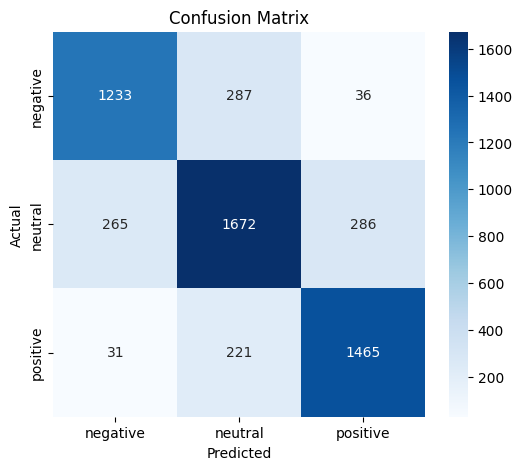

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Confusion Matrix Interpretation

The confusion matrix shows that most predictions are correctly classified along the diagonal, **confirming the model’s strong performance.**     
The model correctly predicted 1233 negative, 1672 neutral, and 1465 positive tweets.       
Most errors occur between neutral and other classes, especially neutral misclassified as negative (265) or positive (286), which is expected due to overlapping sentiment.

Overall, the confusion matrix supports the high accuracy (80%) and shows that the model performs reliably across all sentiment classes.

# Sentiment Prediction Function

With the transformer fully trained, a prediction function is now defined to classify the sentiment of new, unseen tweets.

This function processes the input text using the tokenizer, passes it through the fine-tuned transformer, and returns the predicted sentiment label. It enables the model to be used in real-world scenarios for automatic sentiment analysis.

In [43]:
import torch

def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_class_id = torch.argmax(outputs.logits, dim=1).item()

    return le.inverse_transform([predicted_class_id])[0]

In [54]:
print(predict_sentiment("I love doing this project"))

positive


# Real-World Examples

In [59]:
examples = [

"This actually exceeded my expectations, I’m really happy with it.",

"Bruh I waited all week for this update...... and this is it?",

"It does the job, can’t complain, but nothing impressive honestly.",

"Okay this actually surprised me, didn’t expect it to be this goooood.",

"I regret buying this, but I’m too lazy to return it.",

"They tried… I’ll give them that #effort.",

"This update made everything worse #annoyed"

]

In [60]:
print("Sentiment Predictions:\n")

for text in examples:

    sentiment = predict_sentiment(text)

    print(f"Text      : {text}")
    print(f"Sentiment : {sentiment}")
    print("-" * 70)

Sentiment Predictions:

Text      : This actually exceeded my expectations, I’m really happy with it.
Sentiment : positive
----------------------------------------------------------------------
Text      : Bruh I waited all week for this update...... and this is it?
Sentiment : neutral
----------------------------------------------------------------------
Text      : It does the job, can’t complain, but nothing impressive honestly.
Sentiment : neutral
----------------------------------------------------------------------
Text      : Okay this actually surprised me, didn’t expect it to be this goooood.
Sentiment : positive
----------------------------------------------------------------------
Text      : I regret buying this, but I’m too lazy to return it.
Sentiment : negative
----------------------------------------------------------------------
Text      : They tried… I’ll give them that #effort.
Sentiment : neutral
---------------------------------------------------------------------

# Conclusion

In this project, we built and compared multiple models for sentiment classification, including **XGBoost (72%)**, **Logistic Regression (73%)**, and **transformer-based BGE models (79% and 80%)**.

Traditional machine learning models provided solid baseline performance, but the **transformer model significantly outperformed** them, achieving the highest accuracy of 80% and the **most balanced F1-scores** across all sentiment classes.

This improvement is due to the transformer’s ability to understand context, tone, and subtle meaning, which is essential for real-world human language.

Overall, the transformer-based model proved to be the most effective and reliable approach for sentiment analysis, and this project demonstrates the clear advantage of modern deep learning methods over traditional techniques for natural language understanding tasks.